In [1]:
#Step 1: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10,5)

In [2]:
#Step 2: Load Data
customers = pd.read_csv("../data/customers.csv")
sales = pd.read_csv("../data/sales.csv")

In [3]:
#Convert dates:

sales["OrderDate"] = pd.to_datetime(sales["OrderDate"])

In [5]:
#Step 3: Choose Analysis Date
#RFM always uses a reference date.

snapshot_date = sales["OrderDate"].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2026-07-21 00:00:00')

In [6]:
#Step 4: Calculate RFM Metrics
rfm = sales.groupby("CustomerID").agg({
    "OrderDate": lambda x: (snapshot_date - x.max()).days,
    "OrderID": "count",
    "Sales": "sum"
})

rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
1,2,7,48032.09
2,81,9,119368.91
3,8,11,116553.53
4,55,13,117756.05
5,43,11,101702.65


In [7]:
#Step 5: Descriptive Statistics
rfm.describe()

,Recency,Frequency,Monetary
count,10000.000000,10000.000000,10000.000000
mean,73.270700,10.000000,108511.910963
std,71.277189,3.153093,44214.239155
min,1.000000,1.000000,1603.550000
25%,21.000000,8.000000,76873.262500
50%,51.000000,10.000000,104401.995000
75%,102.000000,12.000000,135886.382500
max,544.000000,24.000000,326977.230000


In [9]:
#Step 6: Create RFM Scores
#Recency Score
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    4,
    labels=[4,3,2,1]
)

In [10]:
#Frequency Score
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"],
    4,
    labels=[1,2,3,4]
)

In [11]:
#Monetary Score
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    4,
    labels=[1,2,3,4]
)

In [12]:
#Step 7: Create Overall RFM Score
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    +
    rfm["F_Score"].astype(str)
    +
    rfm["M_Score"].astype(str)
)
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
1,2,7,48032.09,4,1,1,411
2,81,9,119368.91,2,2,3,223
3,8,11,116553.53,4,3,3,433
4,55,13,117756.05,2,4,3,243
5,43,11,101702.65,3,3,2,332


In [13]:
#Step 8: Customer Segmentation
def segment_customer(row):

    if row["RFM_Score"] == "444":
        return "Champions"

    elif row["R_Score"] == 4 and row["F_Score"] >= 3:
        return "Loyal Customers"

    elif row["M_Score"] == 4:
        return "Big Spenders"

    elif row["R_Score"] == 1:
        return "At Risk"

    else:
        return "Regular Customers"

In [14]:
rfm["Segment"] = rfm.apply(
    segment_customer,
    axis=1
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
CustomerID,,,,,,,,
1,2,7,48032.09,4,1,1,411,Regular Customers
2,81,9,119368.91,2,2,3,223,Regular Customers
3,8,11,116553.53,4,3,3,433,Loyal Customers
4,55,13,117756.05,2,4,3,243,Regular Customers
5,43,11,101702.65,3,3,2,332,Regular Customers


In [15]:
#Step 9: Segment Distribution
segment_counts = (
    rfm["Segment"]
    .value_counts()
)

segment_counts

Segment
Regular Customers    4778
At Risk              2121
Big Spenders         1771
Loyal Customers       804
Champions             526
Name: count, dtype: int64

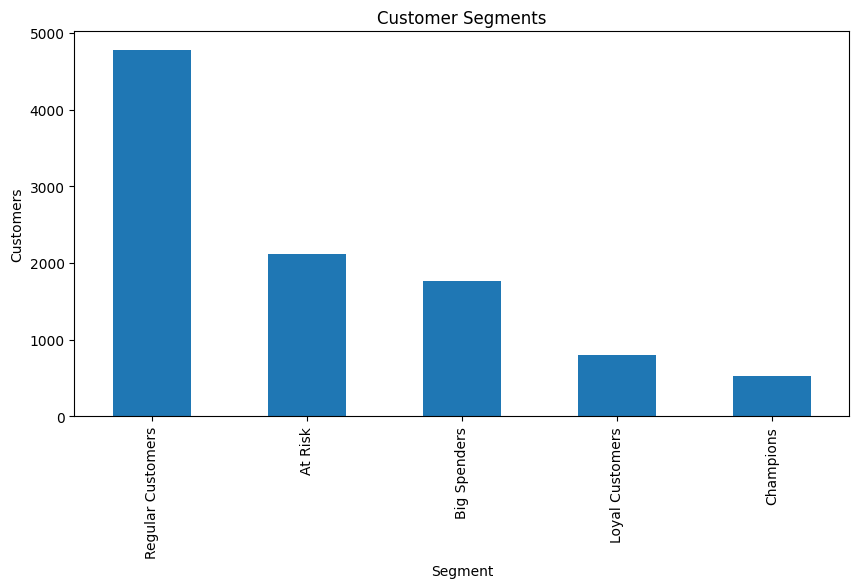

In [16]:
#Step 10: Visualize Segments
segment_counts.plot(
    kind="bar"
)

plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Customers")
plt.show()

In [17]:
#Step 11: Top Customers
top_customers = (
    rfm
    .sort_values(
        by="Monetary",
        ascending=False
    )
    .head(20)
)

top_customers

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
CustomerID,,,,,,,,
9965,52,18,326977.23,2,4,4,244,Big Spenders
1222,36,24,312955.89,3,4,4,344,Big Spenders
5444,34,20,288762.23,3,4,4,344,Big Spenders
4614,53,18,281684.01,2,4,4,244,Big Spenders
8355,15,20,276619.95,4,4,4,444,Champions
8376,39,18,276282.90,3,4,4,344,Big Spenders
2264,9,18,273282.00,4,4,4,444,Champions
4037,46,19,272370.15,3,4,4,344,Big Spenders
2651,120,11,271819.99,1,3,4,134,Big Spenders


In [18]:
#Step 12: Export Results
rfm.to_csv(
    "../reports/customer_rfm_analysis.csv"
)

# Customer Segmentation Insights

- Regular Customers form the largest customer segment, indicating a stable and broad customer base with moderate purchase frequency.

- At Risk Customers represent the second-largest segment, highlighting a significant opportunity for customer retention campaigns.

- Big Spenders contribute a substantial share of total revenue despite representing a smaller portion of the customer base.

- Loyal Customers purchase frequently and consistently, making them ideal candidates for long-term loyalty and retention programs.

- Champions represent the smallest but most valuable customer segment, achieving the highest overall RFM scores.

---

# Marketing Recommendations

- 🎯 Retain **Champions** through exclusive rewards, VIP memberships, early access to new products, and personalized experiences.

- 💰 Upsell **Big Spenders** with premium products, product bundles, and personalized recommendations to maximize customer lifetime value.

- 🔄 Re-engage **At Risk Customers** using targeted discounts, reminder emails, and limited-time promotional campaigns.

- 🤝 Encourage **Regular Customers** to become Loyal Customers through loyalty programs, reward points, and repeat purchase incentives.

- 📈 Strengthen customer engagement initiatives to help **Loyal Customers** transition into the Champions segment.